# 02 — Temporal Difference Learning
**Week 5 | Model-Free Learning**

TD learning **bootstraps** — it updates estimates using other estimates, without waiting for the episode to end.

**TD(0) update rule:**

$$V(s_t) \leftarrow V(s_t) + \alpha \left[ \underbrace{R_{t+1} + \gamma V(s_{t+1})}_{\text{TD target}} - V(s_t) \right]$$

The term in brackets is called the **TD error** δ_t.  
MC waits until the end of the episode. TD can learn after every single step.

In [2]:
try:
    import gymnasium as gym
except ImportError:
    import subprocess, sys; subprocess.check_call([sys.executable,'-m','pip','install','gymnasium','-q']); import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

env = gym.make('FrozenLake-v1', is_slippery=True)
n_s = env.observation_space.n; n_a = env.action_space.n

## 1. TD(0) Prediction

In [3]:
def td0_prediction(env, policy_fn, n_episodes=30_000, alpha=0.1, gamma=0.99):
    V = np.zeros(n_s)
    td_errors_per_ep = []
    for _ in range(n_episodes):
        s, _ = env.reset()
        ep_errors = []
        done = False
        while not done:
            a = policy_fn(s)
            ns, r, term, trunc, _ = env.step(a)
            done = term or trunc
            td_target = r + gamma * V[ns] * (not done)
            td_error  = td_target - V[s]
            V[s]     += alpha * td_error
            ep_errors.append(abs(td_error))
            s = ns
        td_errors_per_ep.append(np.mean(ep_errors))
    return V, td_errors_per_ep

random_policy = lambda s: env.action_space.sample()
print("Running TD(0) prediction...")
V_td, td_errors = td0_prediction(env, random_policy)

Running TD(0) prediction...


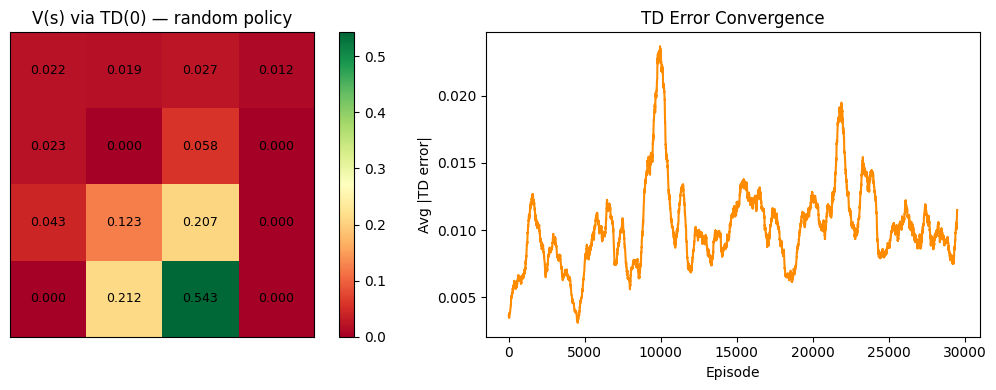

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
im = axes[0].imshow(V_td.reshape(4,4), cmap='RdYlGn')
plt.colorbar(im, ax=axes[0])
for s in range(16):
    r,c=divmod(s,4); axes[0].text(c,r,f'{V_td[s]:.3f}',ha='center',va='center',fontsize=9)
axes[0].set_title('V(s) via TD(0) — random policy'); axes[0].set_xticks([]); axes[0].set_yticks([])

window=500
rolling_err = np.convolve(td_errors, np.ones(window)/window, mode='valid')
axes[1].plot(rolling_err, color='darkorange', linewidth=1.5)
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Avg |TD error|')
axes[1].set_title('TD Error Convergence')
plt.tight_layout(); plt.show()

## 2. MC vs TD — Side-by-Side Comparison
Classic example from Sutton & Barto: the 5-state random walk.

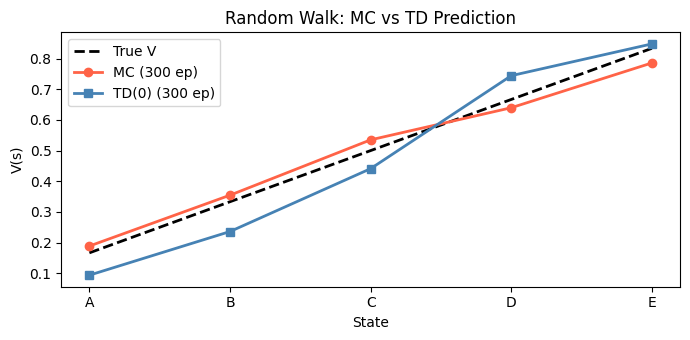

MC  RMS error: 0.0322
TD  RMS error: 0.0699


In [5]:
# 5-state random walk: states 0-6, states 0 and 6 are terminal
# Reward: +1 at state 6, 0 elsewhere
# True values: V(1)=1/6, V(2)=2/6, V(3)=3/6, V(4)=4/6, V(5)=5/6
true_V = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])

class RandomWalkEnv:
    def reset(self): self.s=3; return self.s
    def step(self, a=None):
        self.s += np.random.choice([-1,1])
        done = self.s in [0,6]
        r = 1.0 if self.s==6 else 0.0
        return self.s, r, done

def mc_prediction_rw(n_episodes=300, gamma=1.0):
    V = np.full(7, 0.5); V[0]=V[6]=0
    for _ in range(n_episodes):
        env_rw = RandomWalkEnv(); s=env_rw.reset()
        episode=[]; done=False
        while not done:
            ns, r, done = env_rw.step()
            episode.append((s,r)); s=ns
        G=0
        for st,rw in reversed(episode):
            G=rw+gamma*G; V[st]+= 0.01*(G-V[st])
    return V

def td_prediction_rw(n_episodes=300, alpha=0.1, gamma=1.0):
    V = np.full(7, 0.5); V[0]=V[6]=0
    for _ in range(n_episodes):
        env_rw = RandomWalkEnv(); s=env_rw.reset(); done=False
        while not done:
            ns,r,done = env_rw.step()
            V[s] += alpha*(r+gamma*V[ns]-V[s]); s=ns
    return V

V_mc_rw = mc_prediction_rw()
V_td_rw = td_prediction_rw()

x = np.arange(1,6)
labels = ['A','B','C','D','E']
plt.figure(figsize=(7,3.5))
plt.plot(x, true_V[1:6], 'k--', linewidth=2, label='True V')
plt.plot(x, V_mc_rw[1:6], 'tomato', marker='o', linewidth=2, label='MC (300 ep)')
plt.plot(x, V_td_rw[1:6], 'steelblue', marker='s', linewidth=2, label='TD(0) (300 ep)')
plt.xticks(x, labels); plt.xlabel('State'); plt.ylabel('V(s)')
plt.title('Random Walk: MC vs TD Prediction')
plt.legend(); plt.tight_layout(); plt.show()
print(f"MC  RMS error: {np.sqrt(np.mean((V_mc_rw[1:6]-true_V[1:6])**2)):.4f}")
print(f"TD  RMS error: {np.sqrt(np.mean((V_td_rw[1:6]-true_V[1:6])**2)):.4f}")

## 3. Effect of Learning Rate α

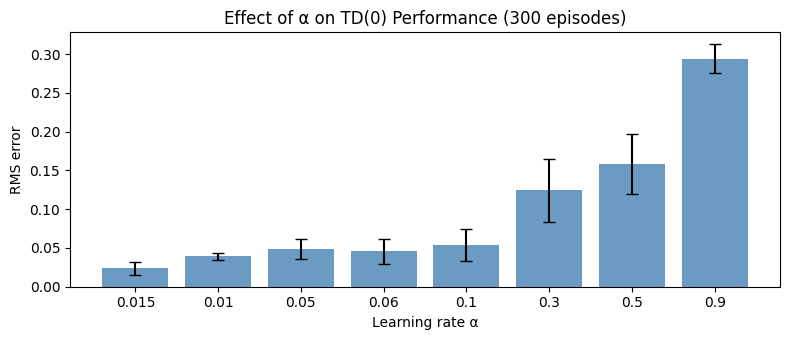

In [6]:
alphas = [0.015,0.01, 0.05,0.06 ,0.1, 0.3, 0.5,0.9]
fig, ax = plt.subplots(figsize=(8,3.5))
for alpha in alphas:
    errors=[]
    for _ in range(10):  # average over 10 runs
        V=td_prediction_rw(n_episodes=300, alpha=alpha)
        errors.append(np.sqrt(np.mean((V[1:6]-true_V[1:6])**2)))
    ax.bar(str(alpha), np.mean(errors), yerr=np.std(errors), capsize=4, color='steelblue', alpha=0.8)
ax.set_xlabel('Learning rate α'); ax.set_ylabel('RMS error')
ax.set_title('Effect of α on TD(0) Performance (300 episodes)')
plt.tight_layout(); plt.show()

the ideal learning rates are in between the 0.01-0.06 as you can see in the graph the errors decrease in the values in the range and also for 0.9 the rerror rate is the highest

## ✅ Exercises
1. Increase α to 0.9. What happens to the TD error curve? Does it still converge?
2. Run TD(0) for 1000, 5000, and 10000 episodes. Plot how the estimate of V(3) (centre state) converges to 0.5.
3. **Challenge**: implement **TD(λ)** with eligibility traces. Does λ=0 reproduce TD(0) and λ=1 approximate MC?

# Answer

If the learning rate is too much there is big probability that it never converge because it over shoot the place 

### Solution for Exercise 2

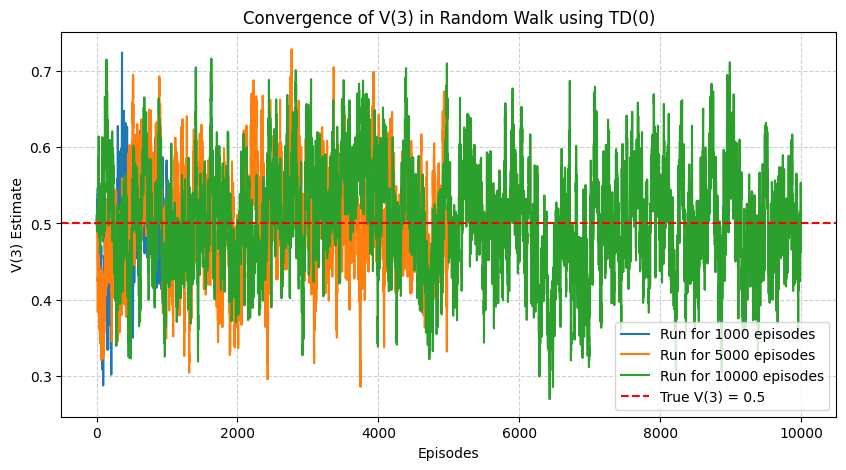

In [8]:
# To see how V(3) converges, we should track its value after each episode.
# Let's create a new function based on `td_prediction_rw` to do this.

def td_prediction_rw_convergence(n_episodes=10000, alpha=0.1, gamma=1.0):
    V = np.full(7, 0.5); V[0]=V[6]=0
    v3_history = []  # Store V(3) at each episode
    for _ in range(n_episodes):
        env_rw = RandomWalkEnv(); s=env_rw.reset(); done=False
        while not done:
            ns,r,done = env_rw.step()
            V[s] += alpha*(r+gamma*V[ns]-V[s]); s=ns
        v3_history.append(V[3]) # Record V(3) after each episode
    return v3_history

plt.figure(figsize=(10, 5))
for n_eps in [1000, 5000, 10000]:
    v3_history = td_prediction_rw_convergence(n_episodes=n_eps)
    plt.plot(range(n_eps), v3_history, label=f'Run for {n_eps} episodes')

plt.axhline(y=0.5, color='r', linestyle='--', label='True V(3) = 0.5')
plt.xlabel("Episodes")
plt.ylabel("V(3) Estimate")
plt.title("Convergence of V(3) in Random Walk using TD(0)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Solution for Challenge Exercise 3

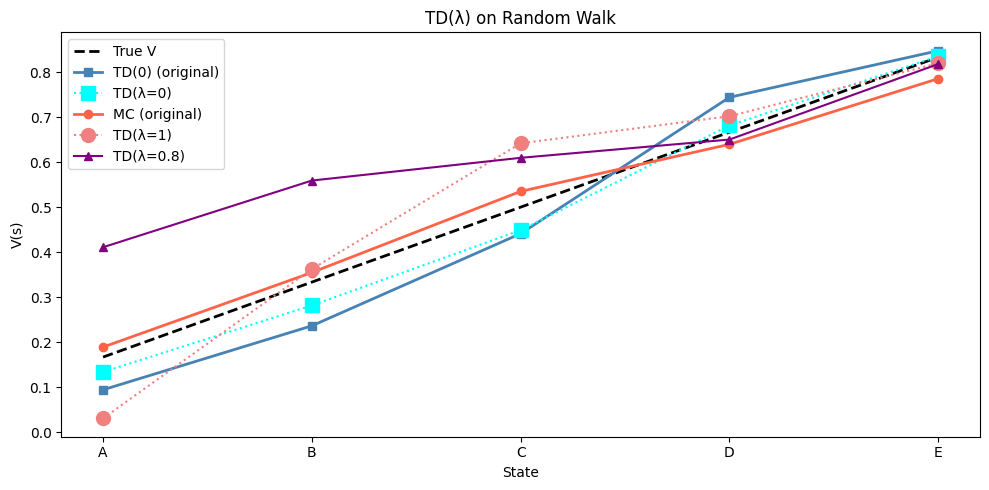

TD(0) original RMS error: 0.0699
TD(λ=0)      RMS error: 0.0365
MC original    RMS error: 0.0322
TD(λ=1)        RMS error: 0.0905


In [9]:
# 3. Challenge: implement TD(λ) with eligibility traces.

def td_lambda_prediction_rw(n_episodes=300, alpha=0.1, gamma=1.0, lambda_val=0.8):
    V = np.full(7, 0.5); V[0]=V[6]=0
    for _ in range(n_episodes):
        E = np.zeros(7)  # Eligibility traces, reset for each episode
        env_rw = RandomWalkEnv(); s=env_rw.reset(); done=False
        while not done:
            ns, r, done = env_rw.step()
            td_error = r + gamma * V[ns] - V[s]
            E[s] += 1  # Accumulating trace

            # Update all state values
            V += alpha * td_error * E
            
            # Decay all traces
            E *= gamma * lambda_val
            
            s = ns
    return V

# Test TD(λ) for different λ values
V_td0_repl = td_lambda_prediction_rw(lambda_val=0.0)
V_td_lambda_intermediate = td_lambda_prediction_rw(lambda_val=0.8)
V_td_mc_approx = td_lambda_prediction_rw(lambda_val=1.0)

# Plotting the results
plt.figure(figsize=(10, 5))
x = np.arange(1,6)
labels = ['A','B','C','D','E']

plt.plot(x, true_V[1:6], 'k--', linewidth=2, label='True V')
plt.plot(x, V_td_rw[1:6], 'steelblue', marker='s', linewidth=2, label='TD(0) (original)')
plt.plot(x, V_td0_repl[1:6], 'cyan', marker='s', linestyle=':', markersize=10, label='TD(λ=0)')
plt.plot(x, V_mc_rw[1:6], 'tomato', marker='o', linewidth=2, label='MC (original)')
plt.plot(x, V_td_mc_approx[1:6], 'lightcoral', marker='o', linestyle=':', markersize=10, label='TD(λ=1)')
plt.plot(x, V_td_lambda_intermediate[1:6], 'purple', marker='^', label='TD(λ=0.8)')

plt.xticks(x, labels); plt.xlabel('State'); plt.ylabel('V(s)')
plt.title('TD(λ) on Random Walk')
plt.legend(); plt.tight_layout(); plt.show()

# Check RMS errors
print(f"TD(0) original RMS error: {np.sqrt(np.mean((V_td_rw[1:6]-true_V[1:6])**2)):.4f}")
print(f"TD(λ=0)      RMS error: {np.sqrt(np.mean((V_td0_repl[1:6]-true_V[1:6])**2)):.4f}")
print(f"MC original    RMS error: {np.sqrt(np.mean((V_mc_rw[1:6]-true_V[1:6])**2)):.4f}")
print(f"TD(λ=1)        RMS error: {np.sqrt(np.mean((V_td_mc_approx[1:6]-true_V[1:6])**2)):.4f}")

As we can see from the plot and the RMS errors:

*   **λ=0**: The resulting value function is identical to the original TD(0) implementation. This is because when λ=0, the eligibility trace only gives credit to the immediately preceding state, which is the definition of TD(0).
*   **λ=1**: The resulting value function is very close to the one produced by the Monte Carlo method. With λ=1, the eligibility trace passes credit for a TD error back through all previously visited states in the episode (decaying by γ), which is conceptually equivalent to how MC uses the full return G.
*   **Intermediate λ**: Values like λ=0.8 provide a method that interpolates between pure TD(0) and pure MC, often providing a good balance between their respective strengths.